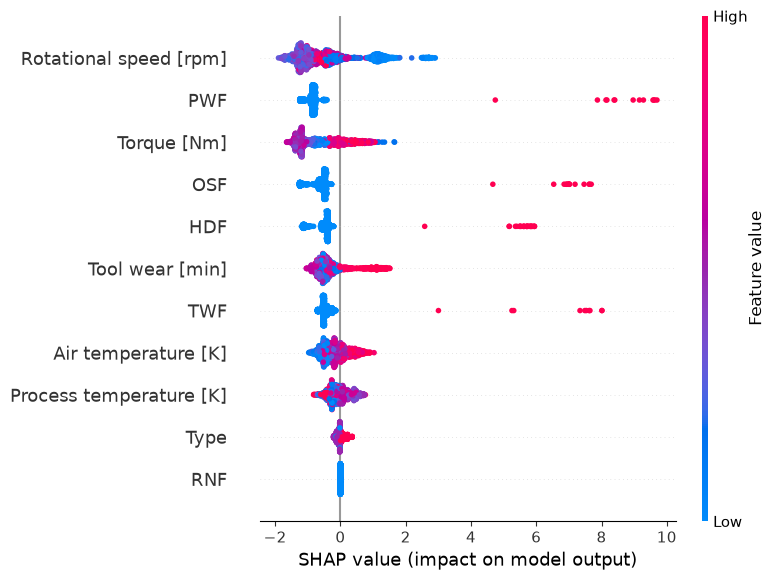

In [3]:
import pandas as pd
import shap

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Load data
df = pd.read_csv("../Output/cleaned_data.csv")

# Encode Type
le = LabelEncoder()
df["Type"] = le.fit_transform(df["Type"])

# X and y
X = df.drop(columns=["Machine failure"])
y = df["Machine failure"]

# Save feature names
feature_names = X.columns

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# XGBoost model
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# SHAP explainer
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

# SHAP summary
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names
)